# Work on the basis of Session 1 statistic 
1. Data from seaborn official website to practice my session 1 statistics  
    - Diamonds Data
    - Titanic Data

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

In [2]:
Data1 = sns.load_dataset("diamonds")
Data2 = sns.load_dataset("titanic")

print("diamond:", Data1.shape)
print("titanic:", Data2.shape)

diamond: (53940, 10)
titanic: (891, 15)


# work on Diamond Data set


In [3]:
#1. 
Data1.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
#2. 
Data1.shape

(53940, 10)

In [5]:
#3.
Data1.columns

Index(['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'price', 'x', 'y',
       'z'],
      dtype='str')

In [6]:
#4.
Data1.dtypes

carat       float64
cut        category
color      category
clarity    category
depth       float64
table       float64
price         int64
x           float64
y           float64
z           float64
dtype: object

In [7]:
#5.
Data1.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [8]:
#6.
Data1.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [9]:
#7.
Data1['price'].mean()

np.float64(3932.799721913237)

In [10]:
#8.
Data1['price'].median()

np.float64(2401.0)

In [11]:
#9. 
Data1['price'].mode()

0    605
Name: price, dtype: int64

In [12]:
#10.
d1mean = Data1["price"].mean()
d1median = Data1["price"].median()
if d1mean > d1median:
    print("Median Is less and Mean is More,\n distribution is positive and right skewed ")
else:
    print("Mean is less and Median is More,\n  distribution may be negative/left skewed")

Median Is less and Mean is More,
 distribution is positive and right skewed 


The mean price is higher than the median price, suggesting that the distribution of diamond prices is positively (right) skewed. This indicates that a relatively small number of high-priced diamonds pull the mean upward. Therefore, the median may be a more representative measure of the typical diamond price than the mean.

In [13]:
#11.
Data1["price"].min()

np.int64(326)

In [14]:
#12.
Data1["price"].max()

np.int64(18823)

In [15]:
#13.
print(f"range: {Data1["price"].max()-Data1["price"].min()}")

range: 18497


In [16]:
#14.
Data1["price"].var()

np.float64(15915629.42430145)

In [17]:
#15.
Data1["price"].std() # SD
Data1["price"].std(ddof=0)  # Popolation SD
Data1["price"].std(ddof = 1) # Sample SD

np.float64(3989.439738146379)

In [18]:
# #16.
# The SD (standard deviation) of price tells you how spread out the prices are around the average price.

# A small SD means prices tend to be close to the average.
# A large SD means prices vary more widely from the average.

# In other words, it measures the typical amount of variation in price from the mean.


In [19]:
#17.
Q1 = Data1["price"].quantile(0.25)
print("Quantile:",Q1)

Quantile: 950.0


In [20]:
#18.
Q2 = Data1["price"].quantile(0.50)
Q2

np.float64(2401.0)

In [21]:
#19.
Q3 = Data1["price"].quantile(0.75)
Q3

np.float64(5324.25)

In [22]:
#20.
IQR = Q3- Q1
print("IOR:",IQR)

IOR: 4374.25


In [23]:
#21.
print("Lower_bond = ",Q1-1.5*IQR)
LB = Q1-1.5*IQR
LB

Lower_bond =  -5611.375


np.float64(-5611.375)

In [24]:
#22.
print("Upper_bond = ",Q3+1.5*IQR)
UB = Q3+1.5*IQR

Upper_bond =  11885.625


In [25]:
#23. FIND Outlires
price_outliers = Data1[(Data1["price"]  > UB) | (Data1["price"] < LB)]
price_outliers

,carat,cut,color,clarity,depth,table,price,x,y,z
23820,1.17,Ideal,F,VVS1,62.1,57.0,11886,6.82,6.73,4.21
23821,2.08,Ideal,I,SI2,62.0,56.0,11886,8.21,8.10,5.06
23822,1.70,Premium,I,VS2,62.2,58.0,11888,7.65,7.60,4.74
23823,1.09,Ideal,F,IF,61.6,55.0,11888,6.59,6.65,4.08
23824,1.68,Ideal,E,SI2,60.4,55.0,11888,7.79,7.70,4.68
...,...,...,...,...,...,...,...,...,...,...
27745,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01
27746,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11
27747,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56
27748,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04


In [26]:
#24-28. 
print(f"mean: {Data1["carat"].mean()}\nMedian: {Data1["carat"].median()}\nMode: {Data1["carat"].mode()}\nVariance: {Data1["carat"].var()}\nSD: {Data1["carat"].std()}\nQ1: {Data1["carat"].quantile(0.25)},\nQ2: {Data1["carat"].quantile(0.50)}\nQ3: {Data1["carat"].quantile(0.75)}\nIQR: {Data1["carat"].quantile(0.75)-Data1["carat"].quantile(0.25)}")

mean: 0.7979397478680015
Median: 0.7
Mode: 0    0.3
Name: carat, dtype: float64
Variance: 0.22468665982277328
SD: 0.47401124440541836
Q1: 0.4,
Q2: 0.7
Q3: 1.04
IQR: 0.64


In [27]:
# 29.
UB_of_carat = Data1["carat"].quantile(0.75)+1.5*(Data1["carat"].quantile(0.75) - Data1["carat"].quantile(0.25))
UB_of_carat
Outlier_carat = Data1[Data1["carat"]>UB_of_carat]
print(f"Number of carat outliers (> 2.00): {len(Outlier_carat)}")

Number of carat outliers (> 2.00): 1889


### Now Grouped Stats:

In [28]:
#30.
Data1.head(2)
Data1.groupby("cut")["price"].mean()

cut
Ideal        3457.541970
Premium      4584.257704
Very Good    3981.759891
Good         3928.864452
Fair         4358.757764
Name: price, dtype: float64

In [29]:
#31. 
Data1.groupby(by="cut")["price"].median()

cut
Ideal        1810.0
Premium      3185.0
Very Good    2648.0
Good         3050.5
Fair         3282.0
Name: price, dtype: float64

In [30]:
#32.
Data1.groupby("cut")["price"].std()

cut
Ideal        3808.401172
Premium      4349.204961
Very Good    3935.862161
Good         3681.589584
Fair         3560.386612
Name: price, dtype: float64

In [31]:
#33.
Data1.groupby("cut")["cut"].count()
Data1["cut"].value_counts()

cut
Ideal        21551
Premium      13791
Very Good    12082
Good          4906
Fair          1610
Name: count, dtype: int64

In [32]:
#34.
Data1.head(2)
Data1.groupby("color")["price"].mean()

color
D    3169.954096
E    3076.752475
F    3724.886397
G    3999.135671
H    4486.669196
I    5091.874954
J    5323.818020
Name: price, dtype: float64

In [33]:
#35.
Data1.groupby("color")["price"].median()

color
D    1838.0
E    1739.0
F    2343.5
G    2242.0
H    3460.0
I    3730.0
J    4234.0
Name: price, dtype: float64

In [34]:
#36.
Data1.groupby("color")["price"].std()

color
D    3356.590935
E    3344.158685
F    3784.992007
G    4051.102846
H    4215.944171
I    4722.387604
J    4438.187251
Name: price, dtype: float64

In [35]:
Data1.head(2)

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31


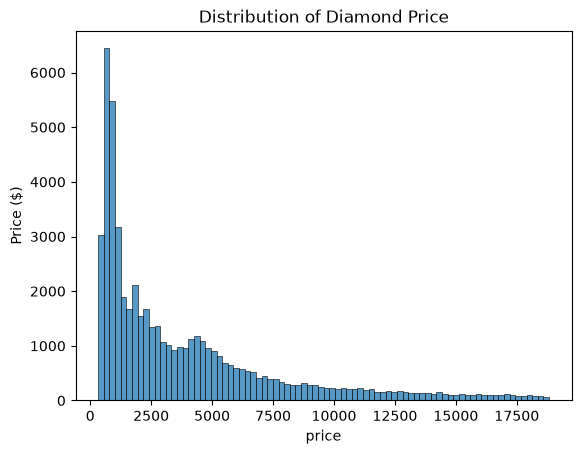

In [37]:
#37. Histogram 
sns.histplot(Data1["price"])
plt.title("Distribution of Diamond Price")
plt.ylabel("Price ($)")
plt.show()


Text(0.5, 1.0, 'Box Blot')

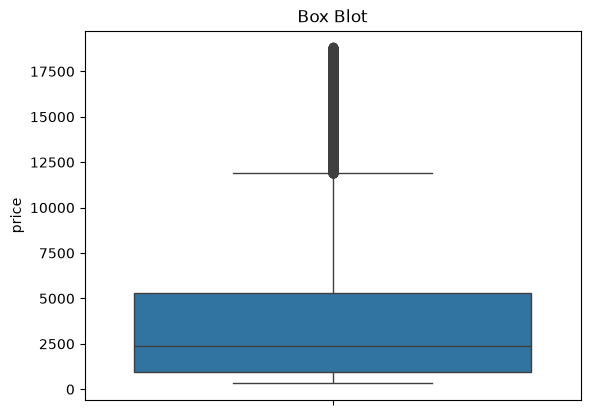

In [51]:
# Box Plot
fig = plt.figure()
sns.boxplot(Data1["price"])
plt.title("Box Blot")


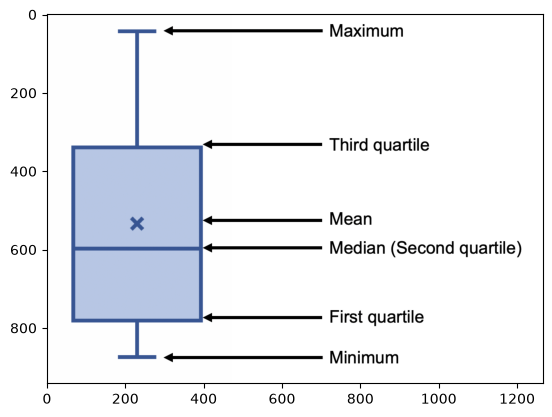

In [ ]:
# Use for Comparing
image = plt.imread("image.png")
plt.imshow(image)

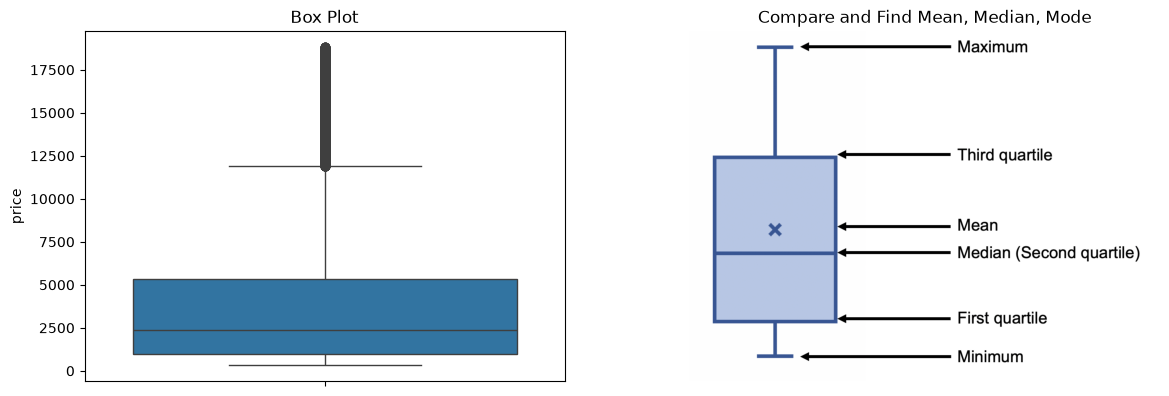

In [ ]:
# improved Version by Use of copy NOtes 
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(12, 5))

# Main plot — left side
ax_main = fig.add_axes([0.05, 0.15, 0.4, 0.7])

sns.boxplot(y=Data1["price"], ax=ax_main)
ax_main.set_title("Box Plot")

# Image — right side
ax_inset = fig.add_axes([0.55, 0.15, 0.4, 0.7])

image1 = plt.imread("image.png")
ax_inset.imshow(image1)
ax_inset.set_title("Compare and Find Mean, Median, Mode")
ax_inset.axis("off")

plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_4820\302519025.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(Data1["carat"],palette="rainbow")


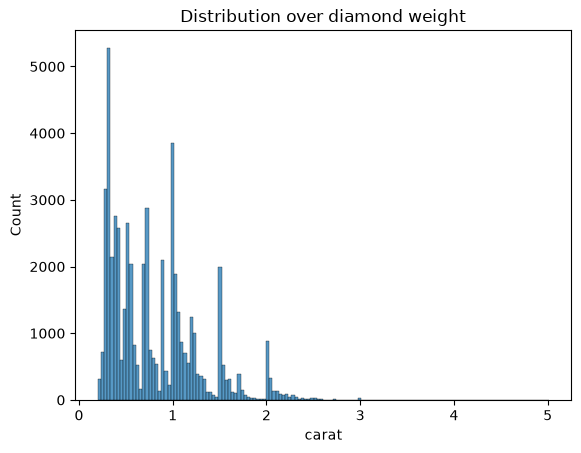

In [ ]:
#39.
sns.histplot(Data1["carat"])
plt.title("Distribution over diamond weight")
plt.show()

C:\Users\Aman\AppData\Local\Temp\ipykernel_4820\3616244391.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cut", y="price", data=Data1,palette="rainbow")


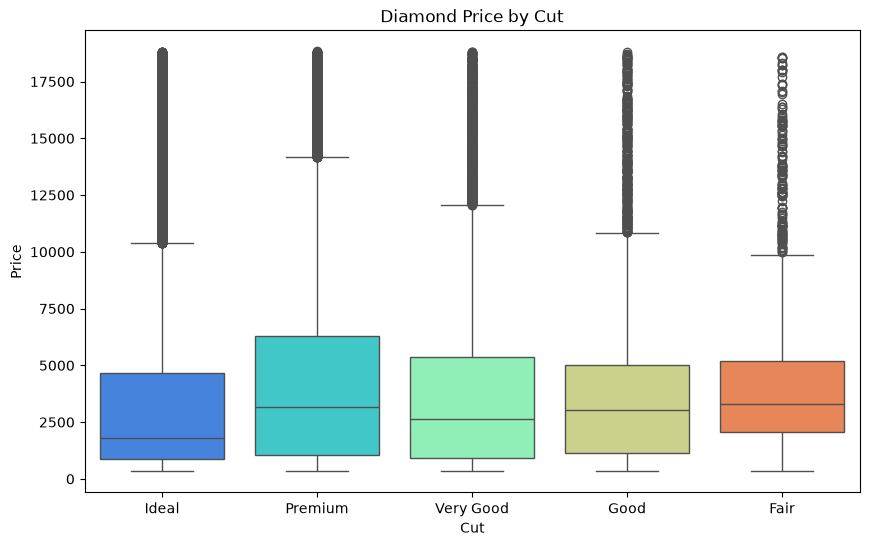

In [90]:
#40.
plt.figure(figsize=(10, 6))
sns.boxplot(x="cut", y="price", data=Data1,palette="rainbow")
plt.title("Diamond Price by Cut")
plt.xlabel("Cut")
plt.ylabel("Price")
plt.show()

<Axes: xlabel='carat', ylabel='price'>

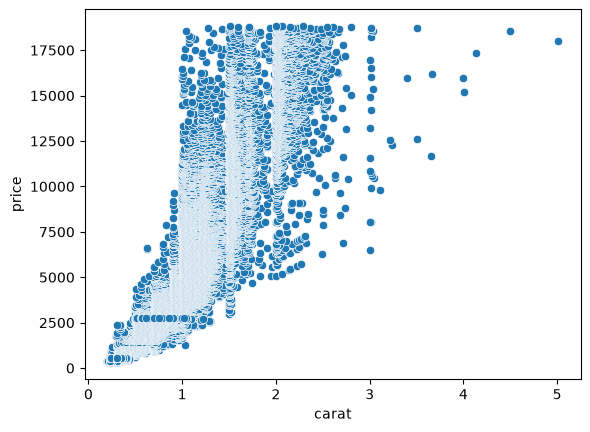

In [ ]:
#41 (1)
sns.scatterplot(x = "carat",y="price",data=Data1)

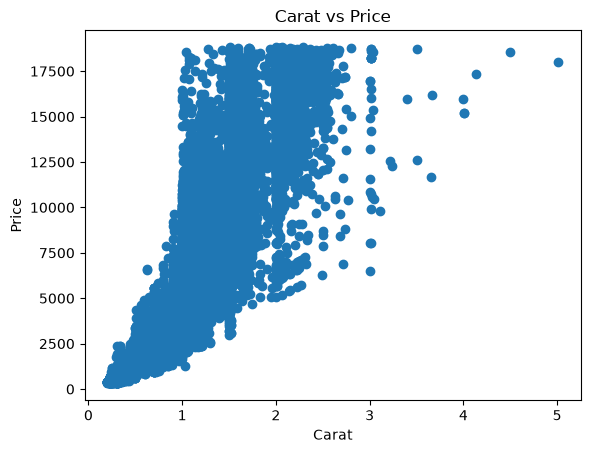

In [ ]:
#41 (2)
plt.scatter(Data1["carat"], Data1["price"])

plt.xlabel("Carat")
plt.ylabel("Price")
plt.title("Carat vs Price")

plt.show()